### What Are Embeddings?
Think of embeddings as a way to translate words into a language that computers understand - numbers!

In [1]:
import numpy as np
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [2]:
# Simplified 2D example (real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

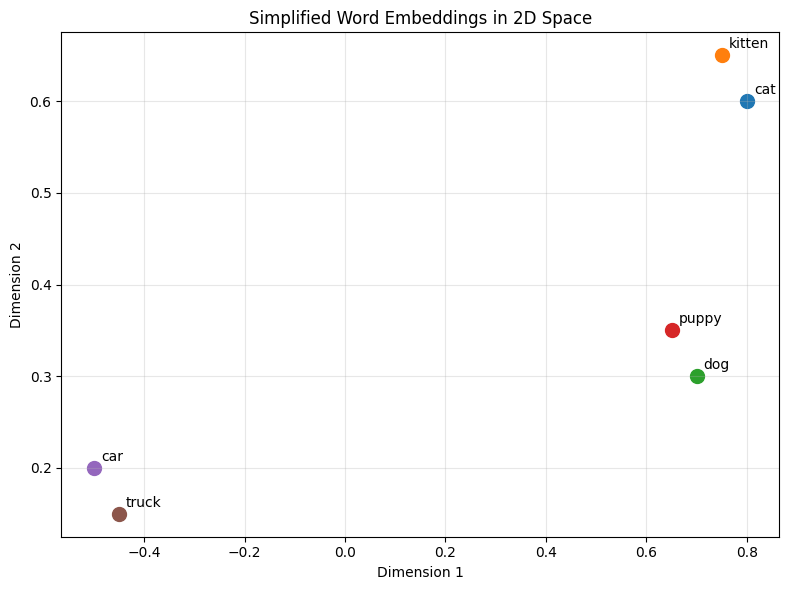

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Measuring Similarity

In [4]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)



In [5]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity=cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [6]:
cosine_similarity(cat_vector,car_vector)

np.float64(-0.43718588548916804)

In [2]:
### Huggingface and OpenAI Models
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

embeddings

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [3]:
### Create your first embeddings
text = "Hello im learning about embeddings and vector databases"
embedding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length: {len(embedding)}")
print(f"Embedding: {embedding}")

Text: Hello im learning about embeddings and vector databases
Embedding length: 384
Embedding: [0.02954106777906418, -0.1265905201435089, -0.030854422599077225, 0.015849603340029716, 0.013873981311917305, 0.028918327763676643, -0.019176995381712914, -0.012203212827444077, -0.04371124133467674, -0.03185683861374855, -0.007278418634086847, 0.04696543514728546, 0.07848202437162399, 0.011493691243231297, -0.12387636303901672, 0.06409968435764313, 0.042248986661434174, 0.06396940350532532, 0.014335906133055687, 0.010587736032903194, -0.08150923252105713, -0.04221309721469879, -0.021925434470176697, -0.04742492735385895, 0.04194388538599014, -0.008330733515322208, 0.011485731229186058, 0.04542885348200798, 0.0323319174349308, -0.05289095640182495, 0.0317872054874897, 0.0032890273723751307, 0.02617228776216507, 0.10370258241891861, -0.09525363147258759, 0.04086210951209068, 0.042781803756952286, -0.008804336190223694, -0.14119045436382294, 0.006562185473740101, 0.0248187817633152, 0.016741225

In [5]:
sentences = [
    "I love machine learning",
    "The cat is on the roof",
    "I enjoy long walks on the beach",
    "The dog is barking loudly",
    "The sun is shining brightly",
    "I dislike rainy days"]
sentence_embeddings = embeddings.embed_documents(sentences)
print(sentence_embeddings[0])
print(sentence_embeddings[1])

[-0.04363635182380676, -0.05905434489250183, 0.08201233297586441, -0.010767162777483463, 0.06119588389992714, -0.05515972524881363, -0.002904382301494479, -0.03672325983643532, 0.021397186443209648, -0.007560407742857933, -0.0717569887638092, 0.05082377791404724, 0.03803318366408348, -0.01625029370188713, -0.03216998279094696, 0.015275165438652039, -0.04679376631975174, 0.017129287123680115, -0.12017451971769333, -0.12222917377948761, -0.0808737501502037, 0.017052792012691498, -0.0208724457770586, 0.005682883784174919, 0.001601448399014771, 0.02626722864806652, 0.02995235286653042, -0.002757032634690404, 0.007171052973717451, -0.06127534061670303, -0.003614461049437523, 0.02485073357820511, 0.025638733059167862, 0.04123907536268234, -0.10209876298904419, 0.00836897362023592, 0.013994366861879826, 0.030988192185759544, 0.024311959743499756, 0.030807770788669586, -0.04405655711889267, -0.013897834345698357, 0.013094749301671982, 0.003649502294138074, 0.07497581094503403, 0.08549104630947

In [6]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")


📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

